In [ ]:
import os
import sys
import seaborn as sns
import matplotlib.pyplot as plt

module_path = os.path.abspath(os.path.join('..','src'))

if module_path not in sys.path:
    sys.path.append(module_path)

from DiagnosisTool.features import clean_breast_cancer_data

module_path = os.path.abspath(os.path.join('..',module_path,'DiagnosisTool'))

if module_path not in sys.path:
    sys.path.append(module_path)

from data import download_breast_cancer_file
from data import load_breast_cancer_data

download_breast_cancer_file()

breast_cancer_data = load_breast_cancer_data()

breast_cancer_data = clean_breast_cancer_data(breast_cancer_data)

breast_cancer_data.describe()

Dataset URL: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data
Dataset URL: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


# Figuras

### Figura 1 - Distribuição de variáveis

A figura 1 apresenta as distribuições das principais variáveis utilizadas
na modelagem, permitindo avaliar assimetria, presença de outliers e justificar
as decisóes de pré-processamento aplicadas

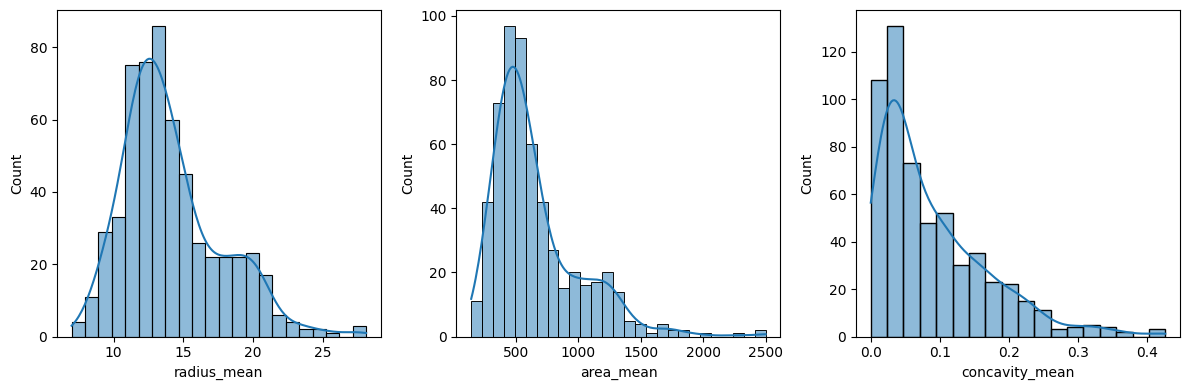

In [ ]:
cols = ["radius_mean", "area_mean", "concavity_mean"]
plt.figure(figsize=(12, 4))
for i, col in enumerate(cols):
    plt.subplot(1, 3, i + 1)
    sns.histplot(breast_cancer_data[col], kde=True)
    plt.title = f"Distribution of {col}"

plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/breast_cancer_data_distributions.png")

plt.show()  

### Figura 2 - Pipeline de Machine Learning

O diagrama do Pipeline de Machine Learning foi elaborado manualmente para representar
as etapas do processo de Machine Learning, desde a entrada dos dados
até a avaliação dos modelos 

### Figura 3 - Matriz de Confusão (Breast Cancer)

A matriz de confusão evidencia a separabilidade entre tumores benignos
e malignos obtida pelo modelo treinado 

Dataset URL: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data


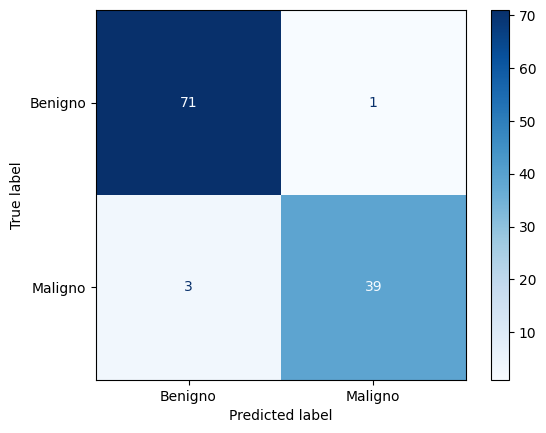

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from DiagnosisTool.data import load_breast_cancer_data
from DiagnosisTool.features import clean_breast_cancer_data, split_breast_cancer_data
from sklearn.model_selection import train_test_split

from pipelines import build_breast_cancer_pipeline

df = load_breast_cancer_data()
df = clean_breast_cancer_data(df)
df.head()

X, y = split_breast_cancer_data(df, "Outcome")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pipeline = build_breast_cancer_pipeline()
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benigno', 'Maligno'])

disp.plot(cmap=plt.cm.Blues)
plt.title = "Confusion Matrix - Breast Cancer Wisconsin Data"
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/breast_cancer_confusion_matrix.png")
plt.show()

### Figura 4 - Curvas ROC

A figura 4 apresenta as curvas ROC (Receiver Operating Characteristics) obtidas
para os modelos de classificação aplicados aos datasets analisados. Essa métrica
avalia a capacidade discriminativa dos modelos independentemente do limiar de
decisão, sendo especialmente relevante em problemas de classificação binária.
A área sob a curva ROC (AUC) indica o desempenho global do modelo, onde valores mais
próximos de 1 representam maior capacidade dde separação entre as classes.

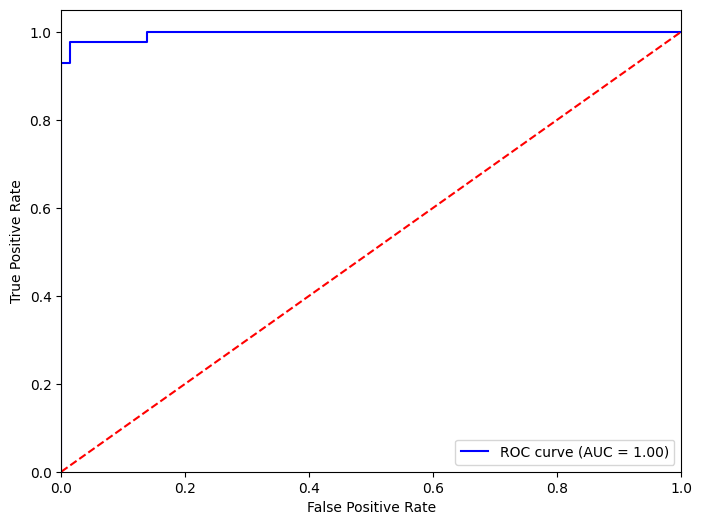

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr) 

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title ='ROC Curve - Breast Cancer Wisconsin Data'
plt.legend(loc="lower right")
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/breast_cancer_roc_curve.png")
plt.show()

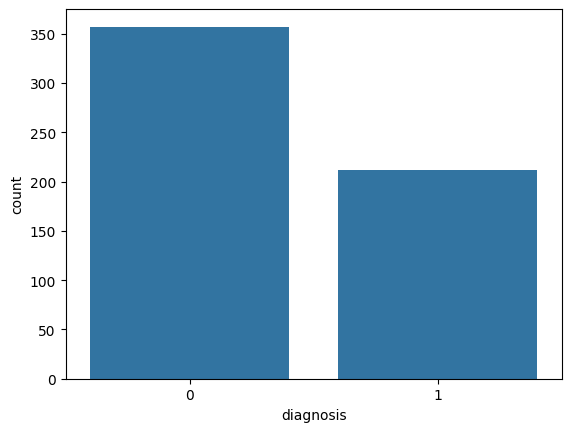

In [ ]:
sns.countplot(x="diagnosis", data=breast_cancer_data)
plt.title="Distribuição das Classes de Diagnóstico (0: Benigno, 1: Maligno)"
plt.show()




# Discussões


### Discussão da variável alvo (diagnóstico)
- Dataset moderamente balanceado
- Leve predominância de tumores benignos
- Métricas além da eficiência são recomendadas

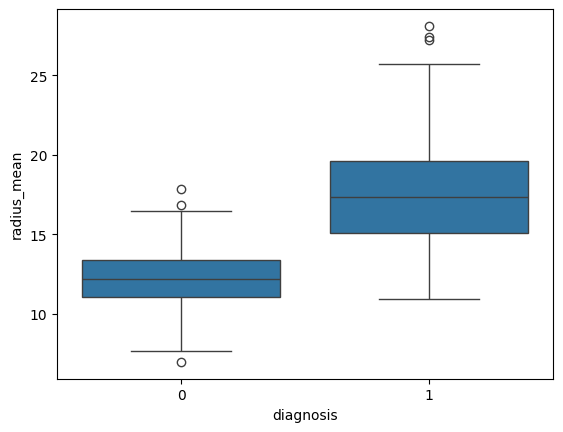

In [ ]:
sns.boxplot(x="diagnosis",y="radius_mean",data=breast_cancer_data)
plt.title="Radius por Classe de Diagnóstico"
plt.show()



### Discussão de Radius por classe
- Tumores malignos apresentam raio (radius) médio maior
- Boa separabilidade visual
- Feature altamente discriminante

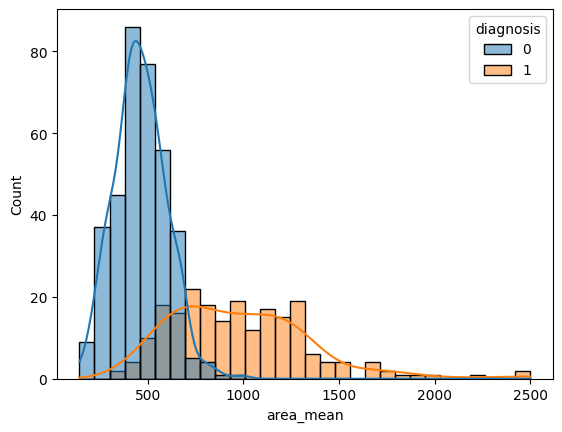

In [ ]:
sns.histplot(data=breast_cancer_data, x="area_mean", hue="diagnosis", kde=True, bins=30)
plt.title="Distribuição de Área por Classe"
plt.show()



### Discussão de Área por Classe
- Distribuição dos malignos deslocada à direita
- Overlap limitado

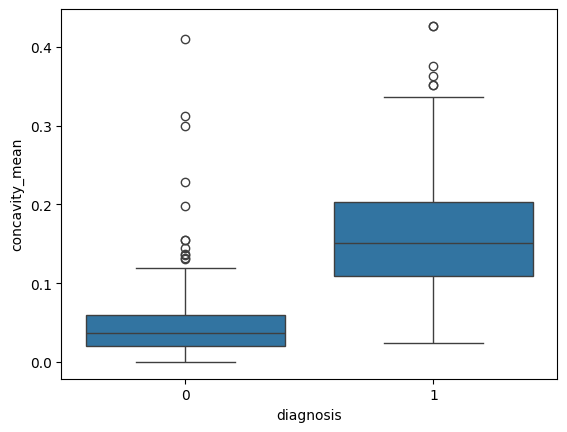

In [ ]:
sns.boxplot(x="diagnosis", y="concavity_mean", data=breast_cancer_data)
plt.title="Distribuição de Concavidade por Classe"
plt.show()



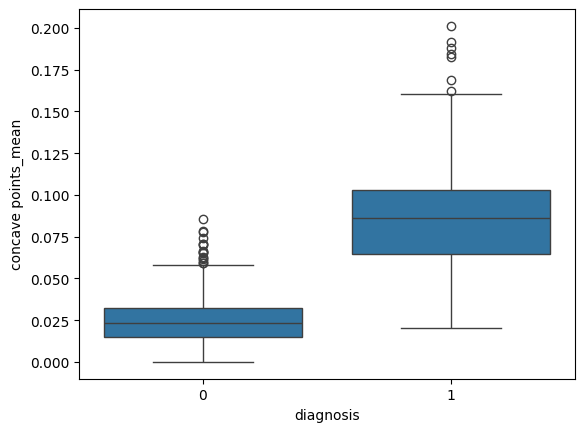

In [ ]:
sns.boxplot(x="diagnosis", y="concave points_mean", data=breast_cancer_data)
plt.title="Distribuição de Pontos Concavos por Classe"
plt.show()



### Discussão sobre Concavity e Concave Points
- Tumores malignos apresentam valores significativamente maiores
- Bordas mais irregulares (maior agressividade tumoral)
- Algumas das features mais importantes do Dataset

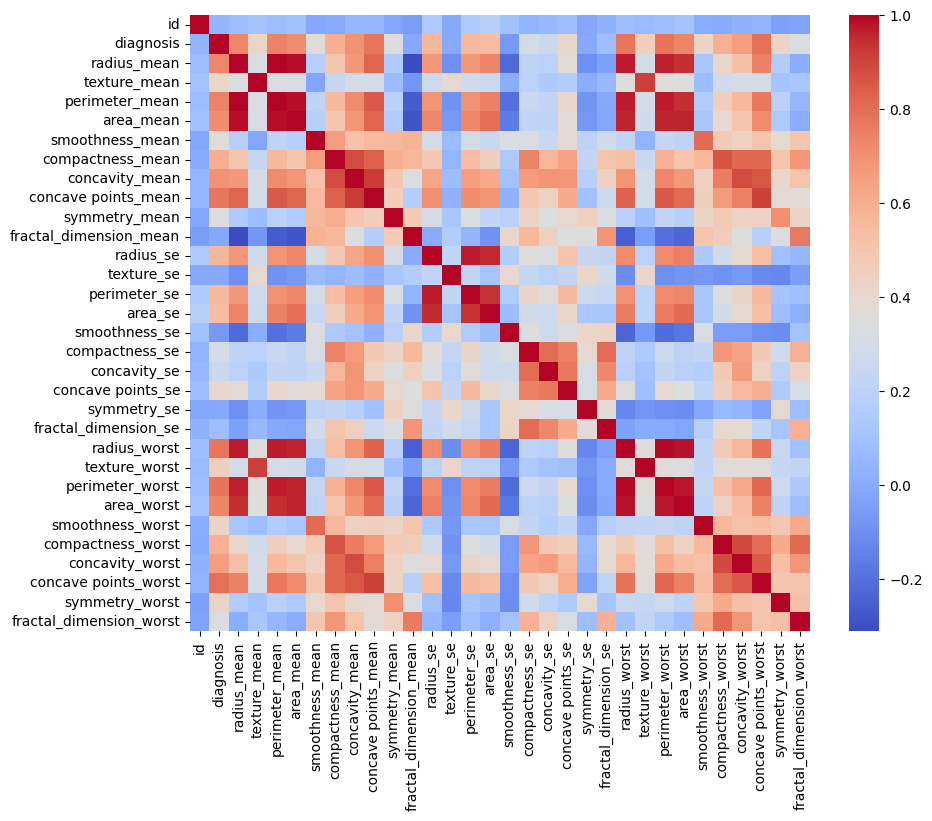

In [ ]:
plt.figure(figsize=(10,8))
breast_cancer_data_numeric = breast_cancer_data.select_dtypes(include=['float64', 'int64'])
sns.heatmap(breast_cancer_data_numeric.corr(), cmap="coolwarm" , annot=False)
plt.show()

### Observações
- Forte correlação entre:
    - Radius, perimeter & area
    - Concavity & Concave Points
- Multicolinearidade presente (modelos lineares podem exigir regularização)

### Discussão geral dos resultados
#### Principais insights
- Features geométricas são altamente discriminativas
    - Radius, perimeter e area apresentam forte separação entre as classes
- Irregularidade de borda é fator-chave
    - Concavity e Concave Points são ótimos indicadores de malignidade
- Features isoladas não bastam
    - Variáveis como texture e smoothness têm baixo poder isoladamente, mas são valiosas em conjunto
- Dataset é limpo e bem estruturado
    - Não há ausência de valores